In [ ]:
# ! pip install category_encoders

# Data Loading

In [1]:
# Import necessary modules
import numpy as np 
import pandas as pd 
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from category_encoders.binary import BinaryEncoder

In [2]:
# ! pip install kagglehub

In [3]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("ealtman2019/credit-card-transactions")

# print("Path to dataset files:", path)

In [4]:
df_users = pd.read_csv("E:\IBM AML Transactions\credit-card-transactions\sd254_users.csv")

In [5]:
df_users.shape

(2000, 18)

In [6]:
df_trans = pd.read_csv("E:\IBM AML Transactions\credit-card-transactions\credit_card_transactions-ibm_v2.csv")

In [7]:
df_trans.shape

(24386900, 15)

In [8]:
unique_Users = df_trans['User'].unique()
selected_cards = pd.Series(unique_Users).sample(frac=0.4, replace=False, random_state=42)
filtered_transactions = df_trans[df_trans['User'].isin(selected_cards)]

In [9]:
df = filtered_transactions.copy()

In [10]:
df.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
28882,2,0,2009,9,26,01:56,$948.44,Online Transaction,3694722044710185708,ONLINE,NaN,NaN,4722,NaN,No
28883,2,0,2009,10,1,04:13,$42.98,Online Transaction,-6458444334611773637,ONLINE,NaN,NaN,4784,NaN,No
28884,2,0,2009,10,1,10:49,$9.85,Swipe Transaction,-4891055843221560993,West Covina,CA,91792.0,5411,NaN,No
28885,2,0,2009,10,1,14:30,$36.39,Online Transaction,-6458444334611773637,ONLINE,NaN,NaN,4784,NaN,No
28886,2,0,2009,10,2,04:25,$56.60,Online Transaction,-6458444334611773637,ONLINE,NaN,NaN,4784,NaN,No


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9688065 entries, 28882 to 24382138
Data columns (total 15 columns):
 #   Column          Dtype  
---  ------          -----  
 0   User            int64  
 1   Card            int64  
 2   Year            int64  
 3   Month           int64  
 4   Day             int64  
 5   Time            object 
 6   Amount          object 
 7   Use Chip        object 
 8   Merchant Name   int64  
 9   Merchant City   object 
 10  Merchant State  object 
 11  Zip             float64
 12  MCC             int64  
 13  Errors?         object 
 14  Is Fraud?       object 
dtypes: float64(1), int64(7), object(7)
memory usage: 1.2+ GB


In [12]:
# Check the number of fraudulent transactions
df['Is Fraud?'].value_counts()

Is Fraud?
No     9676336
Yes      11729
Name: count, dtype: int64

In [13]:
# Check missing value by column
df.isnull().sum()

User                    0
Card                    0
Year                    0
Month                   0
Day                     0
Time                    0
Amount                  0
Use Chip                0
Merchant Name           0
Merchant City           0
Merchant State    1132934
Zip               1197293
MCC                     0
Errors?           9532311
Is Fraud?               0
dtype: int64

# Data Cleaning:

In [14]:
df.Amount.head(5)

28882    $948.44
28883     $42.98
28884      $9.85
28885     $36.39
28886     $56.60
Name: Amount, dtype: object

In [15]:
# We need to strip the '$' from the Amount to cast as a float
df["Amount"]=df["Amount"].str.replace("$","").astype(float)

In [16]:
df.Amount.head(5)

28882    948.44
28883     42.98
28884      9.85
28885     36.39
28886     56.60
Name: Amount, dtype: float64

In [17]:
df.Time.head(5)

28882    01:56
28883    04:13
28884    10:49
28885    14:30
28886    04:25
Name: Time, dtype: object

In [18]:
# Extract the hour and minute to perform a more refined time series analysis
df["Hour"] = df["Time"].str [0:2]
df["Minute"] = df["Time"].str [3:5]
df = df.drop(['Time'],axis=1)

In [19]:
df

,User,Card,Year,Month,Day,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,Hour,Minute
28882,2,0,2009,9,26,948.44,Online Transaction,3694722044710185708,ONLINE,NaN,NaN,4722,NaN,No,01,56
28883,2,0,2009,10,1,42.98,Online Transaction,-6458444334611773637,ONLINE,NaN,NaN,4784,NaN,No,04,13
28884,2,0,2009,10,1,9.85,Swipe Transaction,-4891055843221560993,West Covina,CA,91792.0,5411,NaN,No,10,49
28885,2,0,2009,10,1,36.39,Online Transaction,-6458444334611773637,ONLINE,NaN,NaN,4784,NaN,No,14,30
28886,2,0,2009,10,2,56.60,Online Transaction,-6458444334611773637,ONLINE,NaN,NaN,4784,NaN,No,04,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24382134,1998,0,2020,2,25,10.32,Swipe Transaction,6135208568923449408,Camp Hill,PA,17011.0,9402,NaN,No,15,19
24382135,1998,0,2020,2,26,13.00,Swipe Transaction,6098563624419731578,Lebanon,PA,17042.0,4214,NaN,No,15,06
24382136,1998,0,2020,2,26,32.55,Swipe Transaction,-8516681658274877993,Camp Hill,PA,17011.0,4121,NaN,No,18,51
24382137,1998,0,2020,2,27,8.90,Swipe Transaction,6135208568923449408,Camp Hill,PA,17011.0,9402,NaN,No,15,15


In [20]:
df["Is Fraud?"].value_counts()

Is Fraud?
No     9676336
Yes      11729
Name: count, dtype: int64

In [21]:
df["Is Fraud?"] = df["Is Fraud?"].str.strip().str.lower()

In [22]:
df["Is Fraud?"] = df["Is Fraud?"].apply(lambda x: 1 if x == "yes" else 0)

In [23]:
df["Is Fraud?"].value_counts()

Is Fraud?
0    9676336
1      11729
Name: count, dtype: int64

# EDA:

In [24]:
fraud_data = df[df['Is Fraud?'] == 1]

In [25]:
fraud_data.head()

,User,Card,Year,Month,Day,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,Hour,Minute
44465,2,1,2006,5,25,138.95,Swipe Transaction,3897876142681371300,Algiers,Algeria,NaN,5094,Bad PIN,1,08,39
44466,2,1,2006,5,25,44.95,Swipe Transaction,4878838507642721065,Algiers,Algeria,NaN,5651,NaN,1,12,41
44467,2,1,2006,5,25,28.53,Swipe Transaction,-7231389139399574921,Algiers,Algeria,NaN,5310,NaN,1,12,44
44471,2,1,2006,5,25,37.77,Swipe Transaction,3987158270252316808,Algiers,Algeria,NaN,5921,NaN,1,16,17
57543,2,1,2018,1,10,8.84,Swipe Transaction,2919745757515313025,Rome,Italy,NaN,5932,NaN,1,11,24


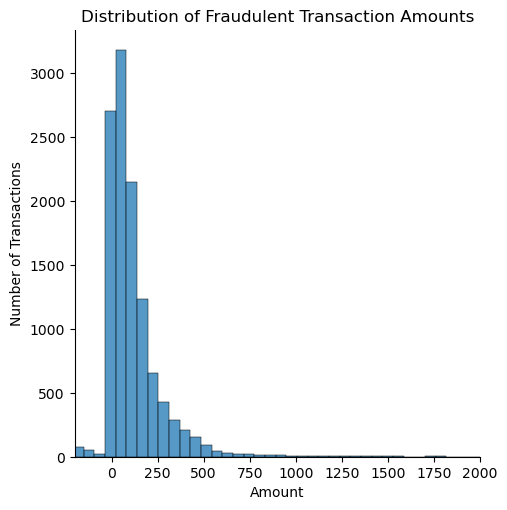

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(fraud_data['Amount'].astype(float), kde=False, bins=80)
plt.title('Distribution of Fraudulent Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Number of Transactions')
plt.xlim(-200, 2000)
plt.show()

### The majority of fraudulent transactions' amount range from 0 to 250, indicating a prevalence of fraud in smaller-value transactions.

### Geographical distribution of fraud transactions:

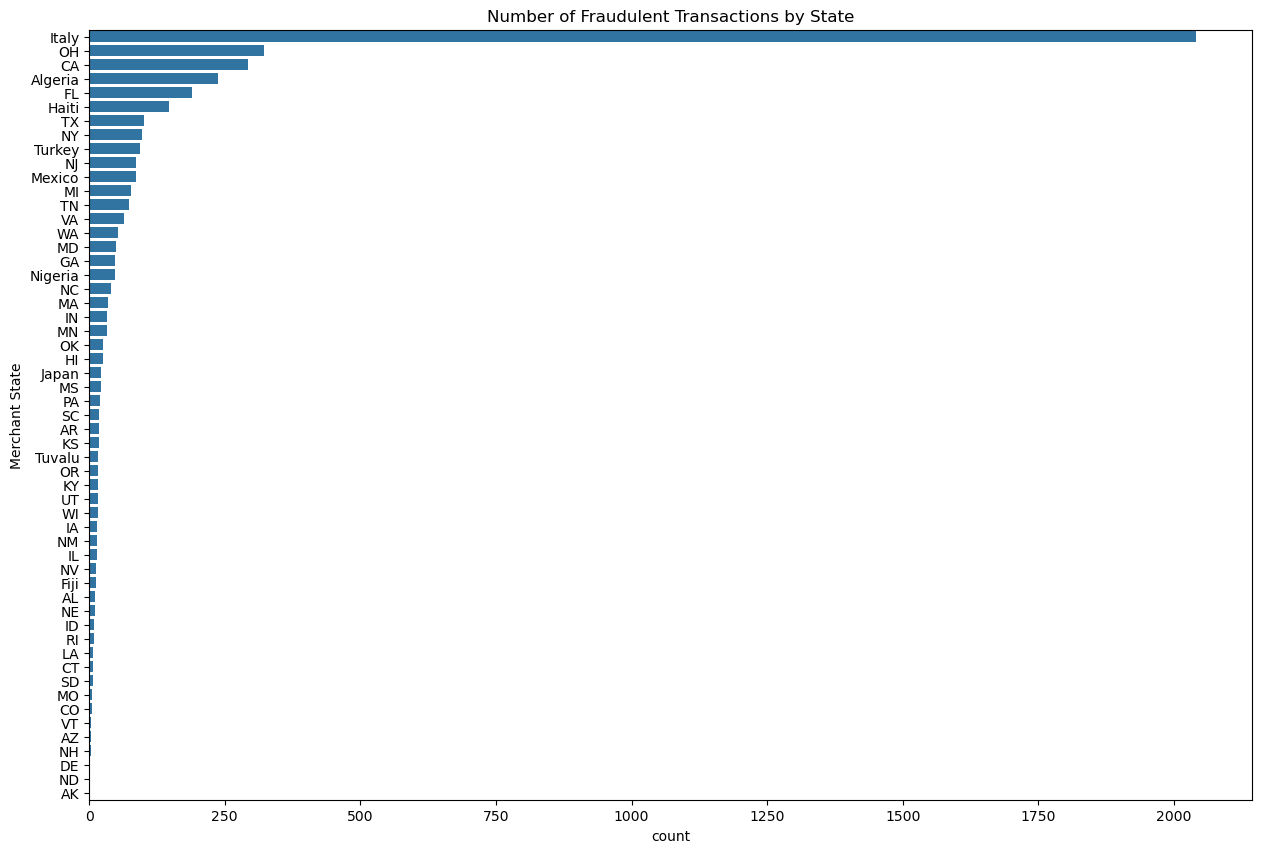

In [27]:
plt.figure(figsize=(15, 10))  
sns.countplot(data=fraud_data, y='Merchant State', order=fraud_data['Merchant State'].value_counts().index)
plt.title('Number of Fraudulent Transactions by State')
plt.show()

### The State contains a mix of US states and other countries, highlighting clear geographical distinctions.

In [39]:
"""1. At the country level, Italy, Algeria, Haiti, and Mexico are the major hotspot for fraudulent activities.
   2. Among US states, Ohio, California, and Florida records the highest incidences of fraud."""

'1. At the country level, Italy, Algeria, Haiti, and Mexico are the major hotspot for fraudulent activities.\n   2. Among US states, Ohio, California, and Florida records the highest incidences of fraud.'

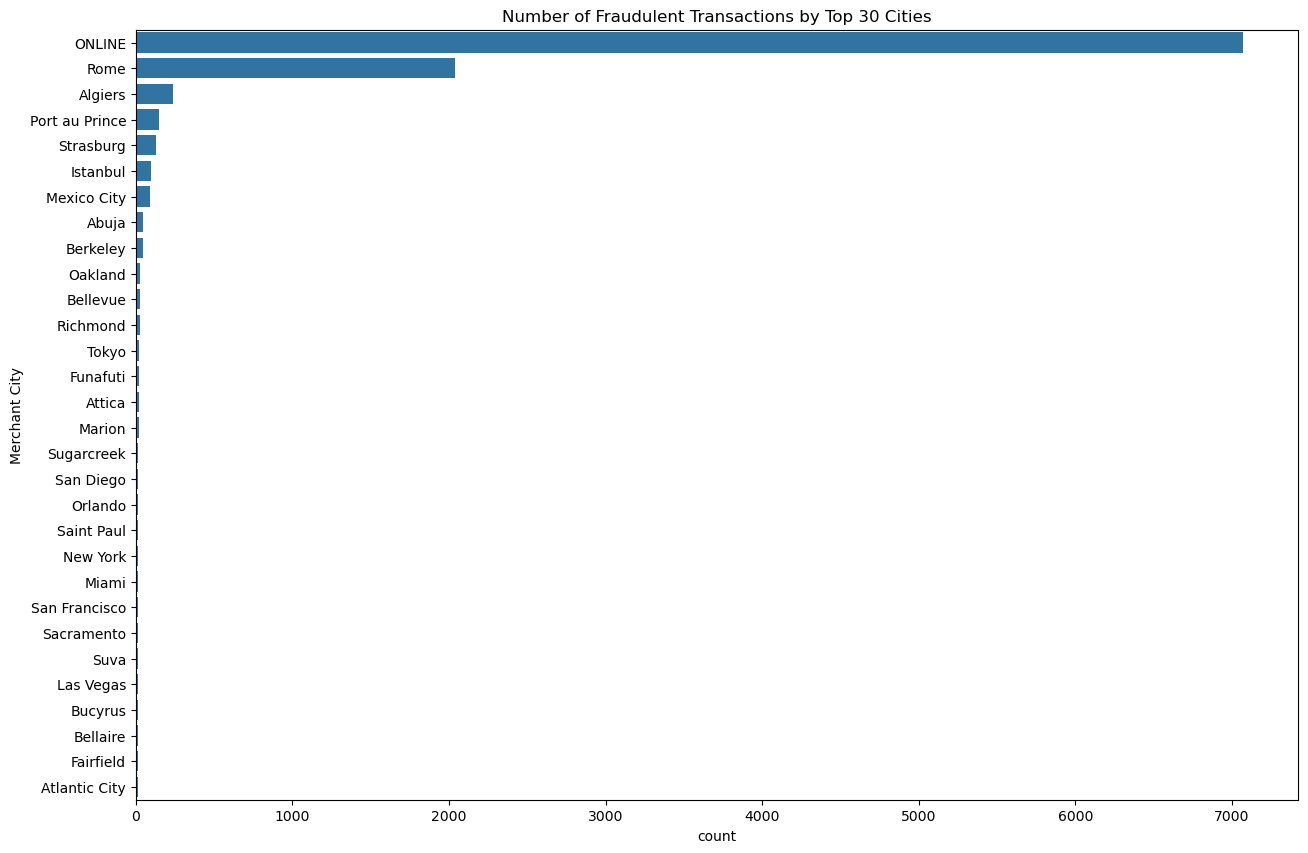

In [40]:
plt.figure(figsize=(15, 10))
top_cities = fraud_data['Merchant City'].value_counts().head(30).index
sns.countplot(data=fraud_data, y='Merchant City', order=top_cities)
plt.title('Number of Fraudulent Transactions by Top 30 Cities')
plt.show()

### Online transactions are the primary venues where fraud predominantly occurs. Additionally, cities such as Rome, Algiers, and Port-au-Prince are notable hotspots for high frequencies of fraudulent activities.

### (3) Time Variation:

###### 1.By year:

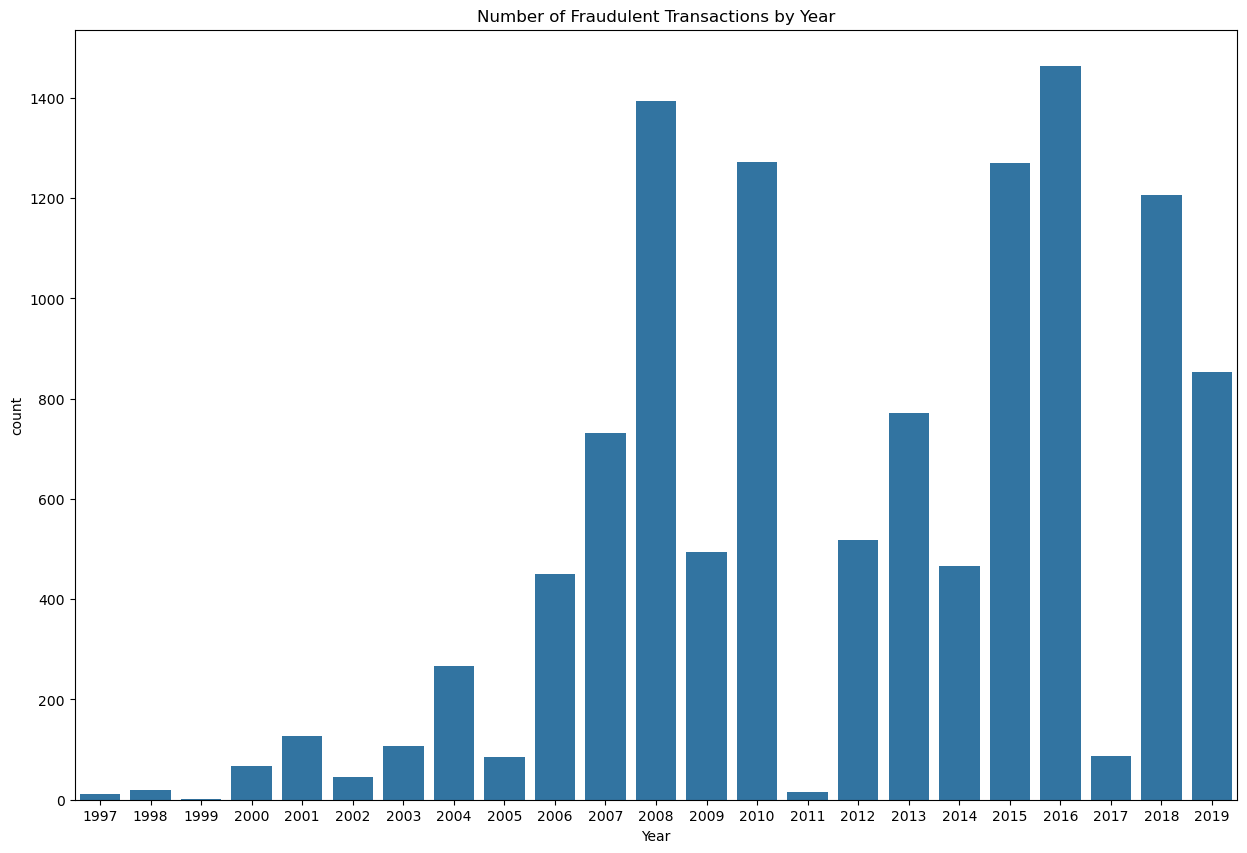

In [42]:
plt.figure(figsize=(15, 10))
sns.countplot(data=fraud_data, x='Year')
plt.title('Number of Fraudulent Transactions by Year')
plt.show()

###### Entering the 21st century, the number of fraud cases has been steadily rising year by year, reaching its peak in 2007-2008 during the Great Recession.


### 2. BY Month:

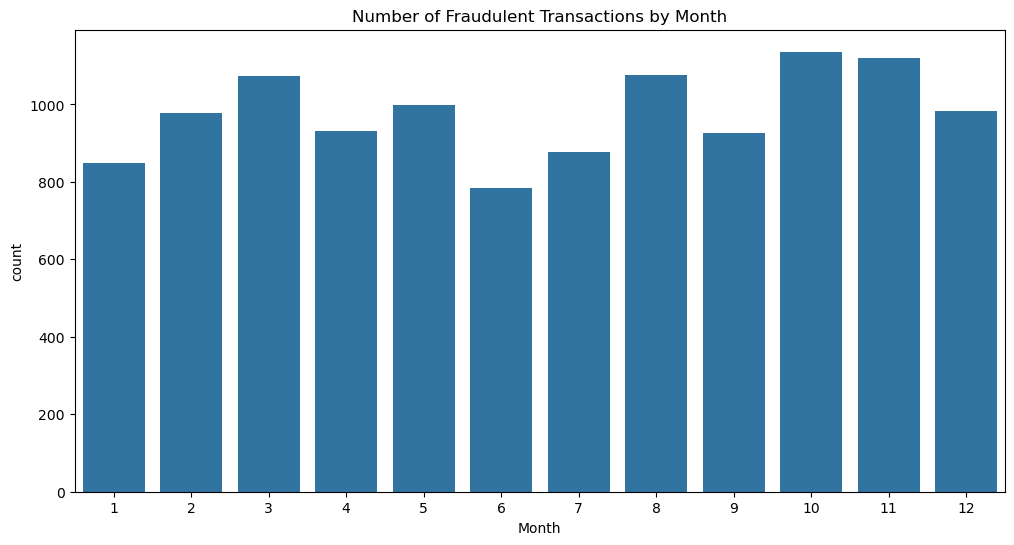

In [43]:
plt.figure(figsize=(12, 6))
sns.countplot(data=fraud_data, x='Month')
plt.title('Number of Fraudulent Transactions by Month')
plt.show()

##### The distribution of fraud cases across months doesn't show significant variations; however, there is a slight uptick in the number of fraud activities towards the end of year.

### 3.By day of month:

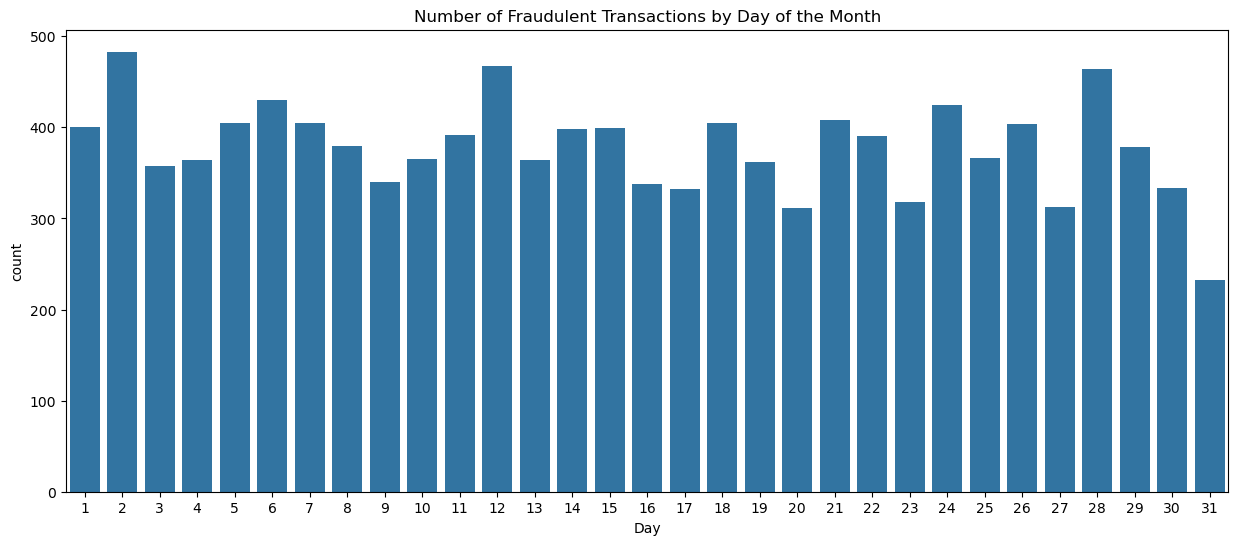

In [44]:
plt.figure(figsize=(15, 6))
sns.countplot(data=fraud_data, x='Day')
plt.title('Number of Fraudulent Transactions by Day of the Month')
plt.show()

##### The spread of fraud cases over the days of the month remains relatively consistent, but there's a minor increase in fraudulent activities as the month draws to a close.

### 4. By day of week:

C:\Users\Tony\AppData\Local\Temp\ipykernel_11312\678193434.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x='Day of Week', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], palette="Blues_d")


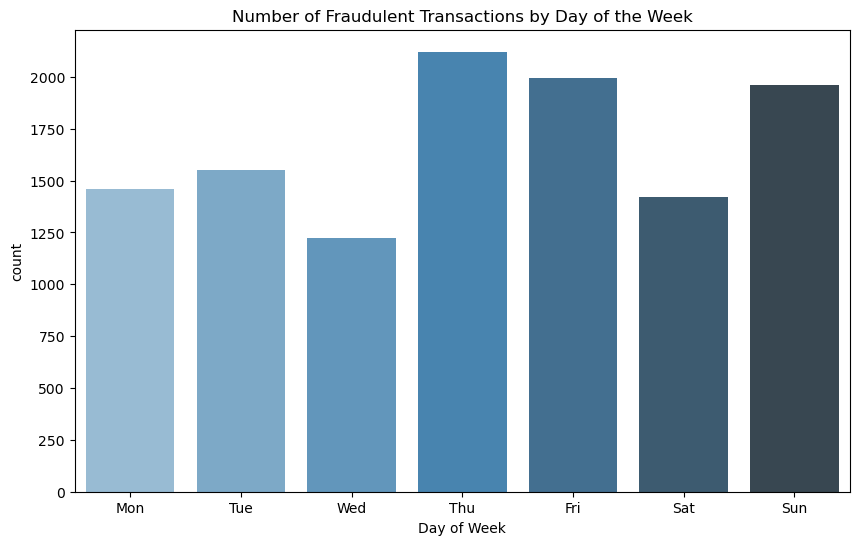

In [45]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# Extract day of the week and map it to its name
days = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['Day of Week'] = df['Date'].dt.dayofweek.map(days)

fraud_data = df[df['Is Fraud?'] == 1]

# Visualize
plt.figure(figsize=(10, 6))
sns.countplot(data=fraud_data, x='Day of Week', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], palette="Blues_d")
plt.title('Number of Fraudulent Transactions by Day of the Week')
plt.show()

##### A higher number of fraud activities occur on Sundays.

##### 5.By hour of day:

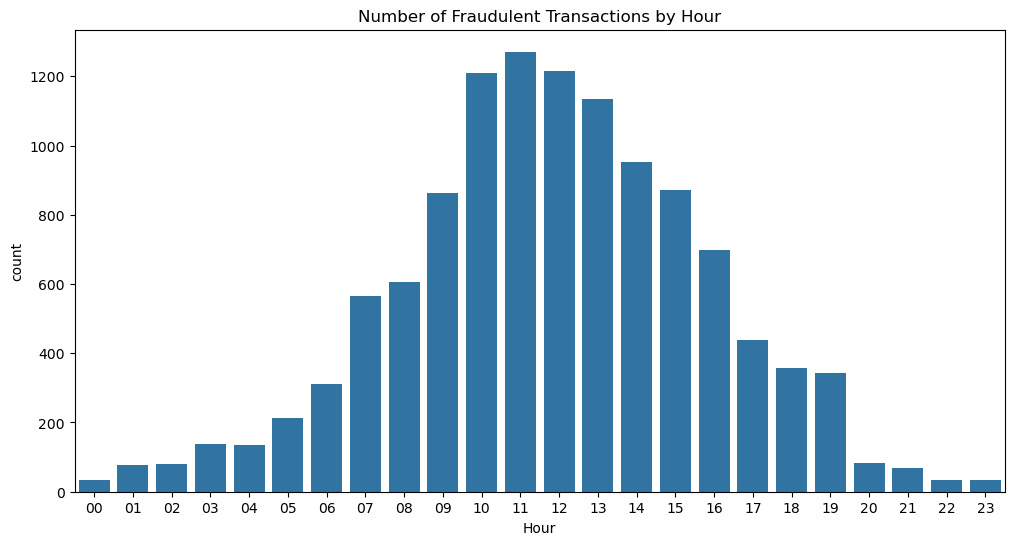

In [46]:
plt.figure(figsize=(12, 6))
sns.countplot(data=fraud_data, x='Hour', order=sorted(fraud_data['Hour'].unique()))
plt.title('Number of Fraudulent Transactions by Hour')
plt.show()

##### Fraud activities predominantly occur between 10 and 11 a.m. local time.

##### (6) Transaction Method :

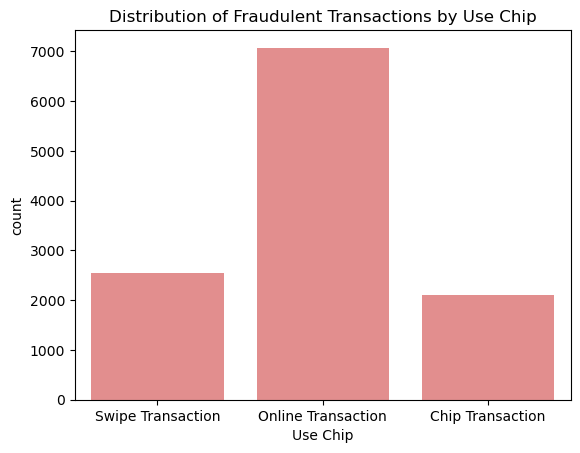

In [47]:
sns.countplot(data=fraud_data, x='Use Chip', color='lightcoral')
plt.title('Distribution of Fraudulent Transactions by Use Chip')
plt.show()

#### Online transactions present the most significant vulnerability to fraud.

### 4. Fraud Detection with Machine Learning :

### (1) Data Preprocessing:

#### 
Based on the EDA above, we will concentrate on variables that appear to exert a more significant impact on the likelihood of a case being fraudulent. Eliminating the variables with high percentage of missing value, we've chosen the following variables for modelling:

Year, Day of Week, Hour, Amount, Use Chip, Merchant Name, Merchant City, MCC.

In [48]:
# Subset specific columns
columns_to_select = ['Year', 'Day of Week', 'Hour', 'Amount', 'Use Chip', 'Merchant Name', 'MCC', 'Is Fraud?']
df = df[columns_to_select]

In [49]:
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

def clean(df):
    # Convert data type
    df['Hour'] = df['Hour'].astype('float')
    
    # Scale the "Amount" column
    scaler = StandardScaler()
    df['Amount'] = scaler.fit_transform(df[['Amount']])
   
    # Binary encoding for categorical variables
    cat_col = ['Use Chip', 'Day of Week']
    for col in cat_col:
        if col in df.columns:
            be = ce.BinaryEncoder(drop_invariant=False)
            enc_df = pd.DataFrame(be.fit_transform(df[col]), dtype='int8')
            df = pd.concat([df, enc_df], axis=1)
            df.drop([col], axis=1, inplace=True)
    
    for col in df.columns:
        df[col] = df[col].astype(float)
        
    return df

# Create the pipeline
preprocessing_pipeline = Pipeline([
    ('cleaning', FunctionTransformer(clean, validate=False)), 
], verbose=True)

df_transformed = preprocessing_pipeline.fit_transform(df)

C:\Users\Tony\AppData\Local\Temp\ipykernel_11312\2935184613.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df['Hour'].astype('float')
C:\Users\Tony\AppData\Local\Temp\ipykernel_11312\2935184613.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Amount'] = scaler.fit_transform(df[['Amount']])


[Pipeline] .......... (step 1 of 1) Processing cleaning, total=  29.1s


### (2) Under sampling:

#####
Due to limitation of computational capacity, I subset 40000 data with 20% of them being fraud cases in order to balance the proportion and ensure model performance.

In [50]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

# Split the dataset into features (X) and target variable (y)
X = df_transformed.drop(columns=['Is Fraud?'])
y = df_transformed['Is Fraud?']

# Calculate the desired number of fraud cases based on the desired proportion
desired_proportion = 0.2
total_samples = 40000
fraud_samples = int(total_samples * desired_proportion)

# Create RandomUnderSampler with the desired sampling strategy
rus = RandomUnderSampler(sampling_strategy={0: total_samples - fraud_samples, 1: fraud_samples}, random_state=1613)

# Apply random undersampling to the original dataset
X_resampled, y_resampled = rus.fit_resample(X, y)

# Split the resampled data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=1613)

##### (3) Predictive Modeling with Random Forest:

In [51]:
# Modeling with Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest Classifier Results:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Results:
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.96      9608
         1.0       0.93      0.77      0.84      2392

    accuracy                           0.94     12000
   macro avg       0.94      0.88      0.90     12000
weighted avg       0.94      0.94      0.94     12000

[[9466  142]
 [ 546 1846]]


#### Precision 0.14¶
The precision of 0.14 for fraud detection is concerning as it indicates that only 14% of flagged transactions are actually fraudulent. This high false positive rate can lead to significant inconvenience for legitimate customers and operational costs for manual reviews.

#####
This code selects 40 percents of transactions related to some users.

In [52]:
used_users = filtered_transactions['User'].unique()
all_users = df_trans['User'].unique()
unused_users = [user for user in all_users if user not in used_users]
validation_transactions = df_trans[df_trans['User'].isin(unused_users)]
validation_transactions

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24386895,1999,1,2020,2,27,22:23,$-54.00,Chip Transaction,-5162038175624867091,Merrimack,NH,3054.0,5541,NaN,No
24386896,1999,1,2020,2,27,22:24,$54.00,Chip Transaction,-5162038175624867091,Merrimack,NH,3054.0,5541,NaN,No
24386897,1999,1,2020,2,28,07:43,$59.15,Chip Transaction,2500998799892805156,Merrimack,NH,3054.0,4121,NaN,No
24386898,1999,1,2020,2,28,20:10,$43.12,Chip Transaction,2500998799892805156,Merrimack,NH,3054.0,4121,NaN,No


In [53]:
df_val = validation_transactions.sample(frac=0.3, replace=False, random_state=42)

In [54]:
df_val = validation_transactions.copy()

In [55]:
# We need to strip the '$' from the Amount to cast as a float
df_val["Amount"]=df_val["Amount"].str.replace("$","").astype(float)

In [56]:
# Extract the hour and minute to perform a more refined time series analysis
df_val["Hour"] = df_val["Time"].str [0:2]
df_val["Minute"] = df_val["Time"].str [3:5]
df_val = df_val.drop(['Time'],axis=1)

In [57]:
# change the is fraud column to binary 
df_val["Is Fraud?"] = df_val["Is Fraud?"].apply(lambda x: 1 if x == 'Yes' else 0)

In [58]:
df_val['Date'] = pd.to_datetime(df_val[['Year', 'Month', 'Day']])

# Extract day of the week and map it to its name
days = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df_val['Day of Week'] = df_val['Date'].dt.dayofweek.map(days)

In [59]:
# Subset specific columns
columns_to_select = ['Year', 'Day of Week', 'Hour', 'Amount', 'Use Chip', 'Merchant Name', 'MCC', 'Is Fraud?']
df_val = df_val[columns_to_select]

In [60]:
df_val_pre = preprocessing_pipeline.fit_transform(df_val)
X_val = df_val_pre.drop(columns=['Is Fraud?'])
y_val = df_val_pre['Is Fraud?']

[Pipeline] .......... (step 1 of 1) Processing cleaning, total=  51.7s


In [61]:
desired_proportion = 0.2
total_samples = 40000
fraud_samples = int(total_samples * desired_proportion)

# Create RandomUnderSampler with the desired sampling strategy
rus = RandomUnderSampler(sampling_strategy={0: total_samples - fraud_samples, 1: fraud_samples}, random_state=42)
X_val_resampled, y_val_resampled = rus.fit_resample(X_val, y_val)

In [62]:
y_val_pred_rf = rf_classifier.predict(X_val_resampled)

print("Random Forest Classifier Results:")
print(classification_report(y_val_resampled, y_val_pred_rf))
print(confusion_matrix(y_val_resampled, y_val_pred_rf))

Random Forest Classifier Results:
              precision    recall  f1-score   support

         0.0       0.75      0.50      0.60     32000
         1.0       0.14      0.32      0.19      8000

    accuracy                           0.47     40000
   macro avg       0.44      0.41      0.40     40000
weighted avg       0.63      0.47      0.52     40000

[[16025 15975]
 [ 5424  2576]]


In [63]:
from lazypredict.Supervised import LazyRegressor

In [64]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit and evaluate models
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

# Display results
print(models)

  0%|          | 0/42 [00:00<?, ?it/s]

  File "C:\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Anaconda3\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht, pi

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 28000, number of used features: 10
[LightGBM] [Info] Start training from score 0.200286
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
XGBRegressor                                 0.76       0.76  0.20        0.58
RandomForestRegressor                        0.75       0.75  0.20       13.64
LGBMRegressor                                0.73       0.73  0.21        0.59
HistGradientBoostingRegressor                0.73       0.73  0.21        2.37
BaggingRegressor                             0.72       0.72  0.21        1.49
ExtraTreesRegressor                       

##### So here we conclude that the below 6 algorithm performs well, So we will fine tune them to make the model more accurate

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',  # Regression objective
    eval_metric='rmse',            # Evaluation metric
    random_state=42,
    n_jobs=-1                      # Use all CPU cores
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Minimize MSE
    cv=5,                              # 5-fold cross-validation
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train,y_train)
regressor_xgb_grid = grid_search.cv_results_
xgb_grid_predictions = grid_search.predict(X_test)

xgb_r2_score = r2_score(y_test, xgb_grid_predictions)
print("The XGB r2_score value for the best parameters{}:".format(grid_search.best_params_),xgb_r2_score)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
The XGB r2_score value for the best parameters{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}: 0.7653687936577167


In [72]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

# Regressors
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    BaggingRegressor,
    ExtraTreesRegressor
)

In [73]:
# Define parameter grids
param_grids = {
    "XGBRegressor": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    },
    "RandomForestRegressor": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5]
    },
    "LGBMRegressor": {
        "n_estimators": [100, 200],
        "num_leaves": [31, 50],
        "learning_rate": [0.05, 0.1]
    },
    "HistGradientBoostingRegressor": {
        "max_iter": [100, 200],
        "max_depth": [None, 10],
        "learning_rate": [0.05, 0.1]
    },
    "BaggingRegressor": {
        "n_estimators": [10, 50],
        "max_samples": [0.5, 1.0],
        "max_features": [0.5, 1.0]
    },
    "ExtraTreesRegressor": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5]
    }
}

In [74]:
# Map names to models
models = {
    "XGBRegressor": XGBRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "LGBMRegressor": LGBMRegressor(random_state=42),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(random_state=42),
    "BaggingRegressor": BaggingRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42)
}

In [75]:
# Run GridSearchCV for each model
best_models = {}
for name, model in models.items():
    print(f"\nRunning GridSearchCV for {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print("Best Params:", grid.best_params_)
    y_pred = grid.predict(X_test)
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Access best models
print("\nBest models summary:")
for name, model in best_models.items():
    print(name, "→", model)


Running GridSearchCV for XGBRegressor...
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Test RMSE: 0.20874379906138196

Running GridSearchCV for RandomForestRegressor...
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Test RMSE: 0.20034497331685996

Running GridSearchCV for LGBMRegressor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 684
[LightGBM] [Info] Number of data points in the train set: 28000, number of used features: 10
[LightGBM] [Info] Start training from score 0.200286
Best Params: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50}
Test RMSE: 0.19367189061188114

Running GridSearchCV for HistGradientBoostingRegressor...
B